Data Cleanning


In [141]:
import pandas as pd 
import numpy as np

In [142]:

df = pd.read_csv('Dataset/HR_Dataset Refresh.csv')
df.head()


,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


In [143]:
date_cols = ['DOB','DateofHire','DateofTermination','LastPerformanceReview_Date']
for col in date_cols:
    df[col]= pd.to_datetime(df[col], errors = 'coerce')

In [144]:
df.isnull().sum()[df.isnull().sum()>0]

DateofTermination    386
ManagerID              8
dtype: int64

In [145]:
df['ManagerID']= df['ManagerID'].fillna(-1).astype (int)
df['ManagerID'].isnull().sum()

np.int64(0)

In [146]:
str_cols = df.select_dtypes('object').columns

In [147]:
df['DateofTermination'].isnull().sum()

np.int64(386)

In [148]:
df['Department']= df['Department'].str.strip().str.title()
df['Gender']= df['Gender'].str.strip().str.title()

In [149]:
df['EmpID'].duplicated().sum()

np.int64(271)

Feature Engineerig

In [150]:
Today = pd.Timestamp.now()
print(Today)

2026-06-08 13:54:54.778183


In [151]:
df['Age']= ((Today-df['DOB']).dt.days/365).astype(int)
df[['Employee_Name','Age']]

,Employee_Name,Age
0,"Adinolfi, Wilson K",42
1,"Ait Sidi, Karthikeyan",51
2,"Akinkuolie, Sarah",37
3,"Alagbe,Trina",37
4,"Anderson, Carol",36
...,...,...
577,"Anderson, Carol",36
578,"Anderson, Linda",49
579,"Andreola, Colby",47
580,"Athwal, Sam",43


In [152]:
df['TenureYears']= (df['DateofTermination'].fillna(Today)-df['DateofHire']).dt.days/365
df['TenureYears']= df['TenureYears'].round(1)
df[['TenureYears','EmpID']]

,TenureYears,EmpID
0,14.9,10026
1,1.2,10084
2,1.2,10196
3,18.4,10088
4,5.2,10069
...,...,...
577,5.2,10069
578,14.4,10002
579,11.6,10194
580,12.7,10062


In [153]:
df['AgeBant']= pd.cut(
    df['Age'],
    bins = [0,30,40,50,60,100],
    labels = ['below 30','30-40','40-50','50-60','Over 60']
)
df['AgeBant'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 582 entries, 0 to 581
Series name: AgeBant
Non-Null Count  Dtype   
--------------  -----   
582 non-null    category
dtypes: category(1)
memory usage: 926.0 bytes


In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Employee_Name               582 non-null    object        
 1   EmpID                       582 non-null    int64         
 2   MarriedID                   582 non-null    int64         
 3   MaritalStatusID             582 non-null    int64         
 4   GenderID                    582 non-null    int64         
 5   EmpStatusID                 582 non-null    int64         
 6   DeptID                      582 non-null    int64         
 7   PerfScoreID                 582 non-null    int64         
 8   FromDiversityJobFairID      582 non-null    int64         
 9   Salary                      582 non-null    int64         
 10  Termd                       582 non-null    int64         
 11  PositionID                  582 non-null    int64         

In [155]:
df['Attrited'] = df['Termd'].astype(int)
cutoff = df['Absences'].quantile(0.75)
df['HighAbsences'] = (df['Absences'] > cutoff).astype(int)


###Conditional Filtering

In [156]:
#filter only active employees
active = df[df['EmploymentStatus']=='Active']
active.shape

(386, 41)

In [157]:
#only employ in it Department
it_item = df[df['Department']=='IT/IS']
it_item

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences,Age,TenureYears,AgeBant,Attrited,HighAbsences


In [158]:

df.PerformanceScore.unique()

array(['Exceeds', 'Fully Meets', 'Needs Improvement', 'PIP'], dtype=object)

In [159]:
high_perf = df[(df['PerformanceScore']=='Exceeds')&
    (df['EmploymentStatus']=='Active')]
high_perf


,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences,Age,TenureYears,AgeBant,Attrited,HighAbsences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,5,0,2019-01-17,0,1,42,14.9,40-50,0,0
5,"Anderson, Linda",10002,0,0,0,1,5,4,0,57568,...,5,0,2019-01-07,0,15,49,14.4,40-50,0,0
12,"Barbossa, Hector",10012,0,2,1,1,3,4,1,92328,...,4,5,2019-02-25,0,9,37,11.6,30-40,0,0
16,"Beak, Kimberly",10023,1,1,0,2,5,4,0,70131,...,3,0,2019-01-14,0,16,60,9.9,50-60,0,0
19,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,5,0,2019-01-17,0,1,42,14.9,40-50,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
560,"Anderson, Linda",10002,0,0,0,1,5,4,0,57568,...,5,0,2019-01-07,0,15,49,14.4,40-50,0,0
564,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,5,0,2019-01-17,0,1,42,14.9,40-50,0,0
569,"Anderson, Linda",10002,0,0,0,1,5,4,0,57568,...,5,0,2019-01-07,0,15,49,14.4,40-50,0,0
573,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,5,0,2019-01-17,0,1,42,14.9,40-50,0,0


In [160]:
high_selry = df['Salary']>70000
high_selry.sum()

np.int64(155)

In [161]:
median_salary = df['Salary'].median()
underpaid = df[
    (df['TenureYears']>=5)&
    (df['Salary']<=median_salary)
][['Employee_Name','Department','TenureYears','Salary']]
underpaid.head()

,Employee_Name,Department,TenureYears,Salary
0,"Adinolfi, Wilson K",Production,14.9,62506
4,"Anderson, Carol",Production,5.2,50825
5,"Anderson, Linda",Production,14.4,57568
7,"Athwal, Sam",Production,12.7,59365
8,"Bachiochi, Linda",Production,16.9,47837


In [162]:
#Basic Status for numbers
df['Salary'].describe().round(1)

count       582.0
mean      73014.0
std       51871.5
min       45046.0
25%       56305.2
50%       62506.0
75%       71758.8
max      650000.0
Name: Salary, dtype: float64

In [163]:
#Which department has highest attraction(quiting rate)?
df.groupby('Department')['Attrited'].mean().sort_values(ascending =False)

Department
It/Is                   0.487805
Production              0.346062
Admin Offices           0.222222
Sales                   0.161290
Software Engineering    0.100000
Executive Office        0.000000
Name: Attrited, dtype: float64

In [164]:
#Average salary per Department
df.groupby('Department')['Salary'].mean().round(0).sort_values(ascending = False)

Department
Executive Office        250000.0
Software Engineering    109334.0
It/Is                    99200.0
Admin Offices            71792.0
Sales                    69061.0
Production               64318.0
Name: Salary, dtype: float64

In [165]:
#count exployees per performances
df['PerformanceScore'].value_counts()

PerformanceScore
Fully Meets          454
Exceeds               97
Needs Improvement     18
PIP                   13
Name: count, dtype: int64

In [166]:
#Do engaged employees miss fewer days?
df.groupby('PerformanceScore')['Absences'].mean().round(1)

PerformanceScore
Exceeds               9.0
Fully Meets          10.7
Needs Improvement    11.3
PIP                   8.3
Name: Absences, dtype: float64

In [169]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="Set2")

#calculate the attrition rate per department

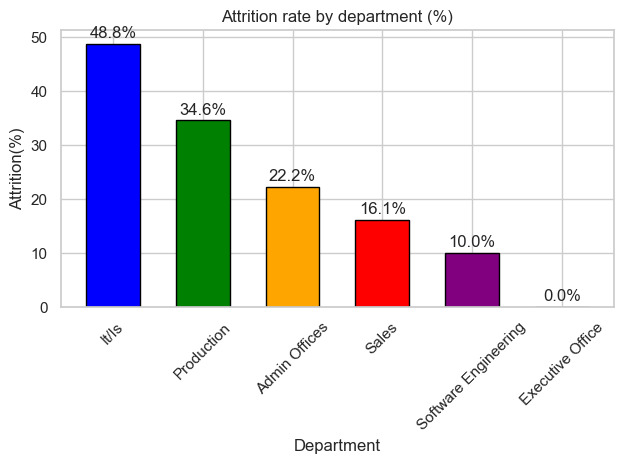

In [210]:
attrition = (
    df.groupby('Department')['Attrited']
    .mean()
    .mul(100)
    .round(1)
    .reset_index()
    .sort_values('Attrited',ascending = False)
)
departments = attrition['Department'].tolist()
values = attrition['Attrited'].tolist()

plt.bar(departments,values, color = ['blue','green','orange','red','purple','yellow'],edgecolor = 'black',width = 0.6)
plt.xlabel('Department')
plt.ylabel('Attrition(%)')
plt.title('Attrition rate by department (%)')
plt.xticks(rotation = 45)
for idx, val in enumerate(values):
    plt.text(idx,val+0.5, str(val)+'%', va = 'bottom', ha = 'center')

plt.tight_layout()
plt.savefig('attrition_by_dept.png')
plt.show()


Salary Distribution (Histogram)

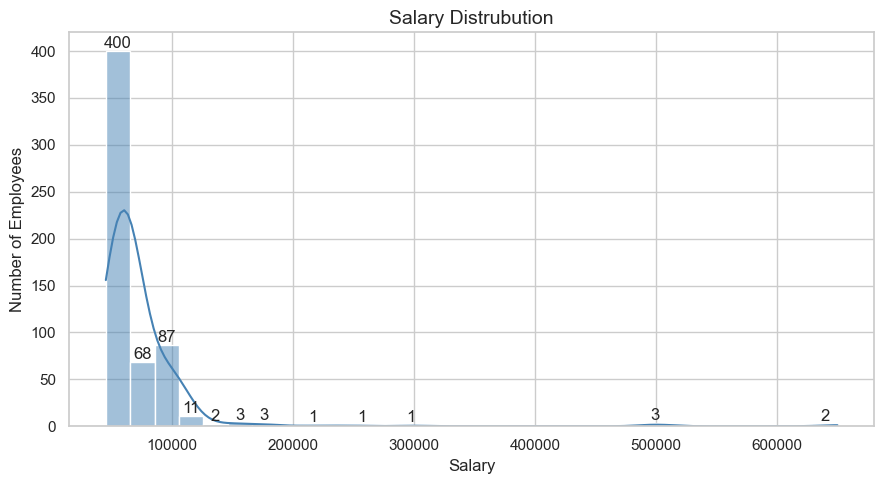

In [220]:
mean_salary = df['Salary'].mean()
median_salry = df['Salary'].median()
plt.figure(figsize=(9, 5))
ax=sns.histplot(df['Salary'], bins = 30, kde = True, color = 'steelblue')
#kde adds the smooth curve on top
plt.title('Salary Distrubution', fontsize= 14)
plt.xlabel('Salary')
plt.ylabel('Number of Employees')
for bar in ax.patches:
    height = bar.get_height()

    if height > 0:  # avoid labeling empty bins
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{int(height)}',
            ha='center',
            va='bottom'
        )
plt.tight_layout()
plt.savefig('salary_disturbution.png',dpi = 150)
plt.show()

Engagement vs Performance

C:\Users\amirx\AppData\Local\Temp\ipykernel_30220\3551663611.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


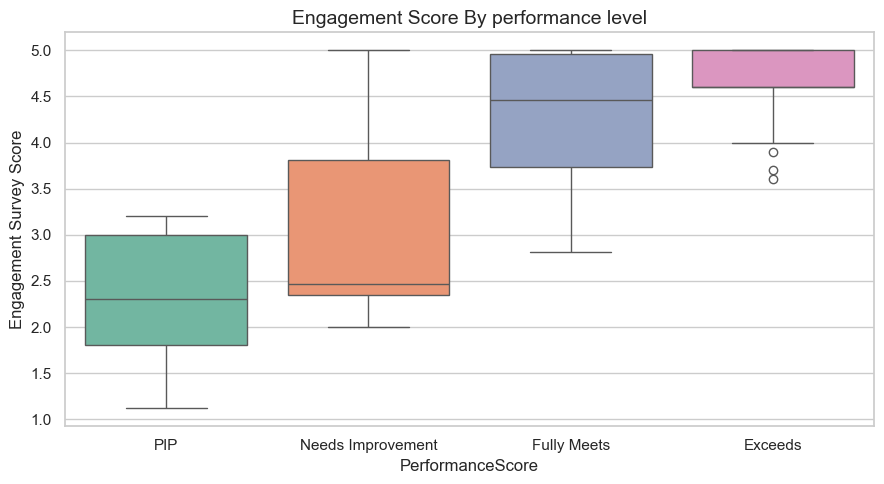

In [224]:
order = ['PIP','Needs Improvement','Fully Meets','Exceeds']
plt.figure(figsize= (9,5))
sns.boxplot(
    data = df,
    x = 'PerformanceScore',
    y = 'EngagementSurvey',
    order = order,
    palette = 'Set2'
    
)
plt.title('Engagement Score By performance level', fontsize = 14)
plt.xlabel('PerformanceScore')
plt.ylabel('Engagement Survey Score')
plt.tight_layout()
plt.savefig('Engagemnet_vs_performance.png',dpi = 150)
legend= False
plt.show()

Absence vs Tenure


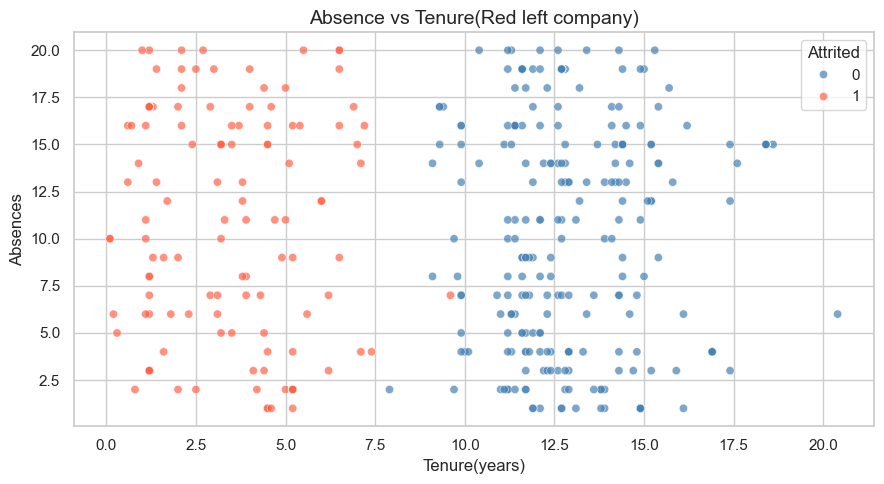

In [225]:
plt.figure(figsize=(9,5))
sns.scatterplot(
    data = df,
    x = 'TenureYears',
    y = 'Absences',
    hue = 'Attrited',
    palette={0:'steelblue',1:'tomato'},
    alpha = 0.7
)
plt.title('Absence vs Tenure(Red left company)', fontsize = 14)
plt.xlabel('Tenure(years)')
plt.ylabel('Absences')
plt.tight_layout()
plt.savefig('absence_vs_Tenure.png',dpi = 150)
plt.show()

